# E-Commerce Sales Dataset Analysis

**Domain**: Sales & E-commerce

**Objective**: The objective of this project is to perform comprehensive Exploratory Data Analysis (EDA) on the E-Commerce Sales dataset using Python. The project aims to analyze overall sales performance, identify top-performing product categories and regions, study sales and profit trends over time, and explore relationships between key business variables to support data-driven decision-making.

**Project Definition**: This project analyzes transactional e-commerce sales data to uncover meaningful patterns, trends, and performance indicators. By applying data cleaning, preprocessing, statistical analysis, and visualization techniques, the project transforms raw sales data into actionable business insights.

**Dataset Description**: The E-Commerce Sales Dataset is sourced from Kaggle and contains transactional records from an online retail platform. The dataset includes information such as order date, product category, region, sales amount, profit, and quantity sold. It enables analysis of sales performance across different categories, regions, and time periods.

**Dataset Source**: Kaggle – E-Commerce Sales Dataset
https://www.kaggle.com/datasets/prince7489/e-commerce-sales

**The scope of this project includes**:

Loading and exploring the dataset using Python.

Cleaning and preprocessing data (handling missing values, duplicates, and data types).

Creating derived features for better analysis.

Performing exploratory data analysis using statistical summaries and visualizations.

Interpreting results and presenting key insights.

**Tools & Technologies Used**:

Python

Pandas

NumPy

Matplotlib

Seaborn

Jupyter Notebook

### Step 1: Import Required Libraries

*Objective*: Set up the Python environment for data analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset

*Objective*: Load the provided dataset into a Pandas DataFrame.

In [ ]:
df = pd.read_csv("C:\\Users\\Aaliya\\Downloads\\Ecommerce_Sales_Data_2024_2025.csv")


### Step 3: Initial Data Overview

*Objective*: Understand the structure and basic characteristics of the dataset.

Number of Rows and Columns

In [ ]:
df.shape


(5000, 18)

Column Names

In [ ]:
df.columns


Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode', 'Year', 'Month', 'Month_Name',
       'Profit_Margin'],
      dtype='object')

Data Types and Null Values

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   Region         5000 non-null   object        
 4   City           5000 non-null   object        
 5   Category       5000 non-null   object        
 6   Sub-Category   5000 non-null   object        
 7   Product Name   5000 non-null   object        
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   int64         
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
 13  Payment Mode   5000 non-null   object        
 14  Year           5000 non-null   int32         
 15  Month          5000 n

Statistical Summary

In [ ]:
df.describe()


,Order ID,Order Date,Quantity,Unit Price,Discount,Sales,Profit,Year,Month,Profit_Margin
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,12500.500000,2024-09-30 18:58:27.840000,2.992600,39760.904600,10.051000,106733.204870,15941.746982,2024.25320,6.479800,0.149239
min,10001.000000,2023-10-04 00:00:00,1.000000,222.000000,0.000000,264.100000,19.120000,2023.00000,1.000000,0.050013
25%,11250.750000,2024-04-05 00:00:00,2.000000,20312.250000,5.000000,39766.537500,4892.295000,2024.00000,4.000000,0.099342
50%,12500.500000,2024-09-29 00:00:00,3.000000,39459.500000,10.000000,83080.325000,11108.525000,2024.00000,6.000000,0.149727
75%,13750.250000,2025-03-30 00:00:00,4.000000,59721.750000,15.000000,156968.587500,22467.987500,2025.00000,9.000000,0.198172
max,15000.000000,2025-10-03 00:00:00,5.000000,79998.000000,20.000000,398485.000000,89688.440000,2025.00000,12.000000,0.249960
std,1443.520003,NaN,1.413133,22831.783946,7.084662,85108.208202,14897.684916,0.65542,3.443307,0.057394


### Step 4: Data Pre-Processing

*Objective*: Clean and prepare the data for accurate analysis.

*Handling Missing Values*

Check for missing values:

In [ ]:
df.isnull().sum()


Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
Year             0
Month            0
Month_Name       0
Profit_Margin    0
dtype: int64

Handle missing values (based on observation):

df.dropna(inplace=True)


*Removing Duplicate Records*

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


*Correcting Data Types*

Convert date columns to datetime format:

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])


In [ ]:
df.dtypes


Order ID                  int64
Order Date       datetime64[ns]
Customer Name            object
Region                   object
City                     object
Category                 object
Sub-Category             object
Product Name             object
Quantity                  int64
Unit Price                int64
Discount                  int64
Sales                   float64
Profit                  float64
Payment Mode             object
Year                      int32
Month                     int32
Month_Name               object
Profit_Margin           float64
dtype: object

*Creating Derived Columns*

*Objective*: Enhance analysis by creating new useful columns.

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()


Create profit margin:

In [ ]:
df['Profit_Margin'] = df['Profit'] / df['Sales']


*Filtering and Aggregating Data*

*Objective*: Summarize data for business insights

Category-wise Sales

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()


Region-wise Profit

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().reset_index()


Monthly Sales Trend

In [ ]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()


**FROM START TO DATA PREPROCESSING**:

The project has successfully covered the foundational phases, beginning with defining the project name, domain, dataset source, objective, and problem definition, which establishes clear business context. The dataset was then loaded into a Pandas DataFrame and explored using head(), shape, info(), and describe() to understand its structure, data types, and basic statistics. During data pre-processing, missing values and duplicates were checked, data types (especially date fields) were corrected, and derived columns such as Year, Month, and Profit Margin were created. At this stage, the dataset is clean, structured, and ready for analysis.

**Next Phase (Overview)**:

The next phase focuses on Exploratory Data Analysis (EDA), where the cleaned data will be analyzed to uncover patterns and trends in sales and profit across categories, regions, and time periods. This will involve aggregation, grouping, and visualizations such as bar charts, line graphs, and scatter plots. The final steps will summarize key insights and conclusions, translating analytical results into meaningful business interpretations and recommendations suitable for decision-making.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("C:\\Users\\Aaliya\\Downloads\\Ecommerce_Sales_Data_2024_2025.csv")

### Step 5: Exploratory Data Analysis (EDA)

**5.1 Univariate Analysis**:

In [ ]:
df[['Sales', 'Profit', 'Quantity']].describe()



,Sales,Profit,Quantity
count,5000.000000,5000.000000,5000.000000
mean,106733.204870,15941.746982,2.992600
std,85108.208202,14897.684916,1.413133
min,264.100000,19.120000,1.000000
25%,39766.537500,4892.295000,2.000000
50%,83080.325000,11108.525000,3.000000
75%,156968.587500,22467.987500,4.000000
max,398485.000000,89688.440000,5.000000


In [ ]:
df['Category'].value_counts()


Category
Books          528
Kitchen        528
Furniture      527
Home Decor     515
Sports         511
Clothing       511
Toys           478
Electronics    472
Groceries      470
Beauty         460
Name: count, dtype: int64

In [ ]:
df['Region'].value_counts()


Region
North    1288
East     1256
West     1241
South    1215
Name: count, dtype: int64

**5.2 Bivariate Analysis**:

*Objective*:To study relationships between two variables.

In [ ]:
df.groupby('Category')['Sales'].sum().reset_index()


,Category,Sales
0,Beauty,50803409.70
1,Books,54932643.00
2,Clothing,55053908.30
3,Electronics,52587883.95
4,Furniture,56647187.90
5,Groceries,47883103.15
6,Home Decor,57233222.35
7,Kitchen,54227902.30
8,Sports,52069397.25
9,Toys,52227366.45


In [ ]:
df.groupby('Region')['Profit'].sum().reset_index()


,Region,Profit
0,East,20532558.12
1,North,21343004.33
2,South,18253049.32
3,West,19580123.14


In [ ]:
df[['Sales', 'Profit']].corr()


,Sales,Profit
Sales,1.000000,0.848792
Profit,0.848792,1.000000


**5.3 Multivariate Analysis**:

*Objective*:To analyze the combined effect of multiple variables.

In [ ]:
df.groupby(['Category', 'Region'])['Sales'].sum().reset_index()


,Category,Region,Sales
0,Beauty,East,12790403.80
1,Beauty,North,13984910.85
2,Beauty,South,12292234.10
3,Beauty,West,11735860.95
4,Books,East,14173354.80
5,Books,North,15441895.30
6,Books,South,12948754.30
7,Books,West,12368638.60
8,Clothing,East,13684994.15
9,Clothing,North,15930578.90


In [ ]:

df.columns


Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month


C:\Users\Aaliya\AppData\Local\Temp\ipykernel_25688\2181219983.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


In [ ]:
df[['Order Date', 'Year', 'Month']].head()


,Order Date,Year,Month
0,2024-10-19,2024,10
1,2025-08-30,2025,8
2,2023-11-04,2023,11
3,2025-05-23,2025,5
4,2025-01-19,2025,1


In [ ]:
df.groupby(['Year', 'Month'])[['Sales', 'Profit']].sum().reset_index()


,Year,Month,Sales,Profit
0,2023,10,21307522.20,3106231.10
1,2023,11,22040269.20,3387740.08
2,2023,12,20624240.25,2989330.92
3,2024,1,21477241.40,3104253.86
4,2024,2,19853396.50,2941448.82
5,2024,3,21571015.35,3235674.53
6,2024,4,22214781.10,3241579.85
7,2024,5,24744786.55,3692958.55
8,2024,6,21368962.50,3261199.09
9,2024,7,24019283.90,3486946.19


In [ ]:
assert 'Year' in df.columns and 'Month' in df.columns


**5.4 Pivot Table Analysis**:

*Objective*:To summarize data across multiple dimensions.

In [ ]:
pd.pivot_table(
    df,
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
)


Region,East,North,South,West
Category,,,,
Beauty,12790403.80,13984910.85,12292234.10,11735860.95
Books,14173354.80,15441895.30,12948754.30,12368638.60
Clothing,13684994.15,15930578.90,13261557.80,12176777.45
Electronics,15165897.55,14439593.55,11880847.80,11101545.05
Furniture,13090179.45,15085776.75,11575306.65,16895925.05
Groceries,12088346.60,14357007.65,9931549.50,11506199.40
Home Decor,15589662.00,17286752.95,12083972.05,12272835.35
Kitchen,12724395.80,10781078.15,13399212.00,17323216.35
Sports,12964689.30,13754083.95,12687812.90,12662811.10


**5.5 Correlation Analysis**

*Objective*:To identify strength and direction of relationships between numerical variables.

In [ ]:
df[['Sales', 'Profit', 'Quantity']].corr()


,Sales,Profit,Quantity
Sales,1.000000,0.848792,0.588705
Profit,0.848792,1.000000,0.502701
Quantity,0.588705,0.502701,1.000000


### STEP 6: DATA VISUALIZATION

**6.1 Category-wise Sales (Bar Plot)**:

*Objective*: Identify top-performing product categories.

In [ ]:
import matplotlib.pyplot as plt


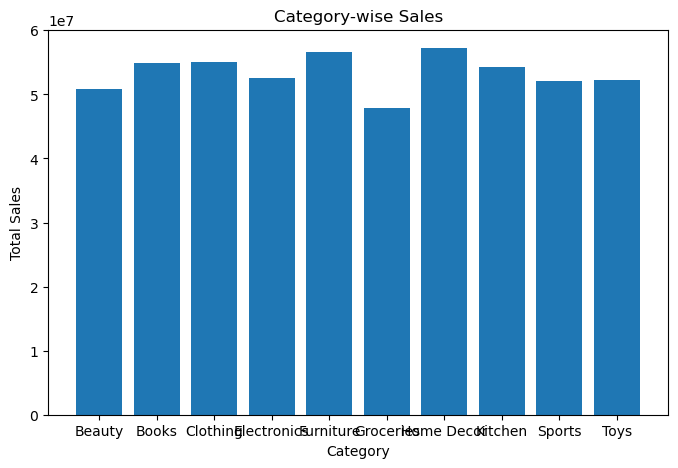

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(category_sales['Category'], category_sales['Sales'])
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


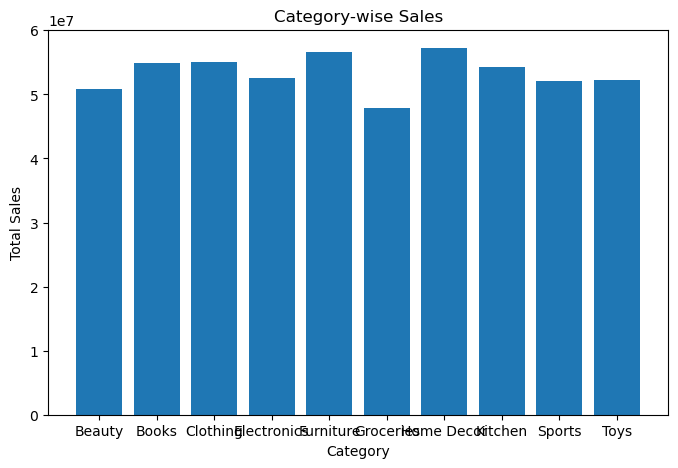

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(category_sales['Category'], category_sales['Sales'])
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()


**6.2 Region-wise Profit (Bar Plot)**:

*Objective*: Compare profit across regions.

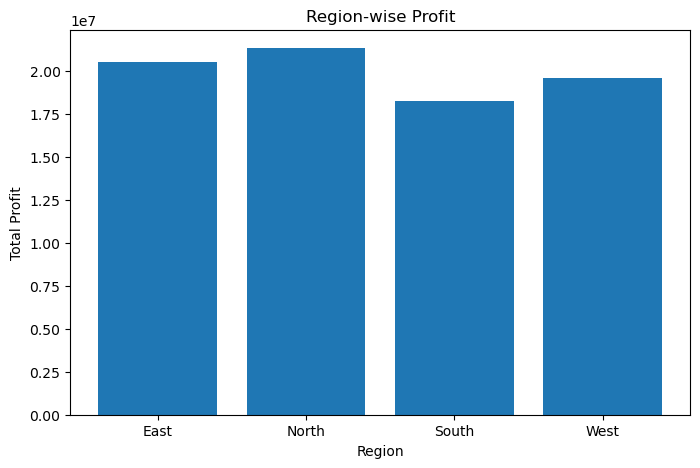

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(region_profit['Region'], region_profit['Profit'])
plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()


**6.3 Sales Trend Over Time (Line Chart)**

*Objective*: Analyze sales trend across time.

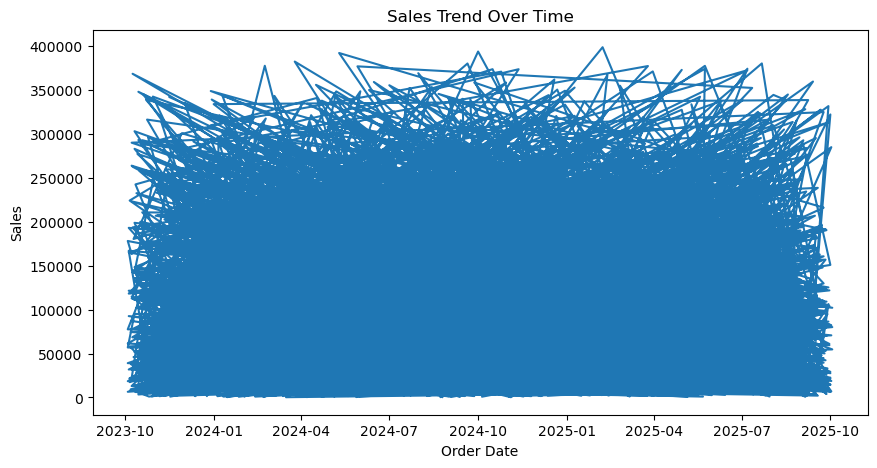

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Order Date'], df['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()


**6.4 Sales vs Profit (Scatter Plot)**:

*Objective*: Understand the relationship between sales and profit.

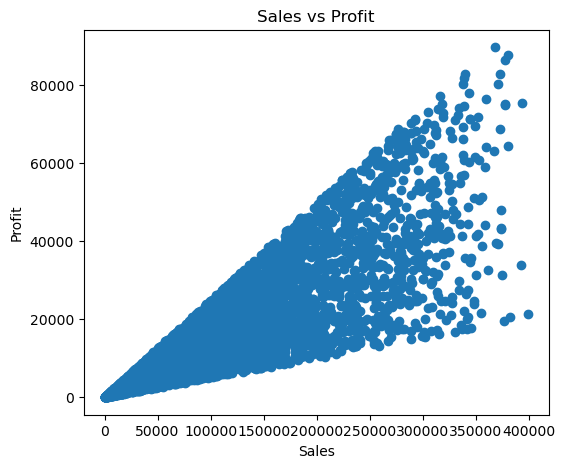

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()


**4.5 Correlation Heatmap**:

*Objective*: Visualize correlation strength.

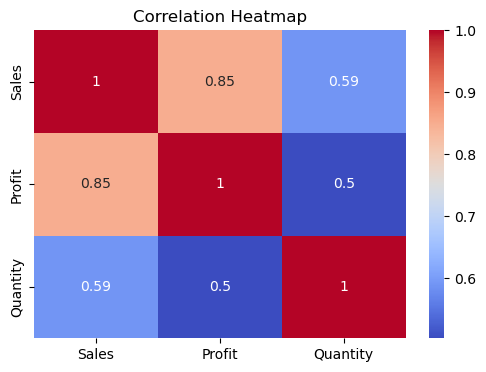

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(
    df[['Sales', 'Profit', 'Quantity']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


**THIS PHASE:**

In the completed phase, the E-Commerce Sales Dataset (2024–2025) was successfully loaded and prepared for analysis using Python. Initial data understanding was performed to examine the dataset structure, data types, and summary statistics. Data preprocessing steps such as handling missing values, removing duplicates, correcting date formats, and creating derived columns (Year, Month, Profit Margin) ensured the dataset was clean and analysis-ready. Exploratory Data Analysis (EDA) was then carried out using statistical summaries and aggregation techniques to identify sales and profit patterns across categories, regions, and time periods. Visualizations such as bar charts, line plots, and scatter plots were used to support and validate analytical findings.

**NEXT PHASE:**

The next phase focuses on insight generation and final reporting. In this stage, results obtained from EDA and visualizations will be interpreted to derive meaningful business insights. Key trends, correlations, and performance indicators will be clearly summarized using Markdown explanations. The project will conclude with a final summary of findings along with practical recommendations and possible future analysis directions to support data-driven decision-making.